In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score, classification_report, confusion_matrix
from autofeat import AutoFeatRegressor 
import featuretools as ft
import seaborn as sns

In [2]:
df = pd.read_csv('../data/AirfoilSelfNoise.csv')
df.head()

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


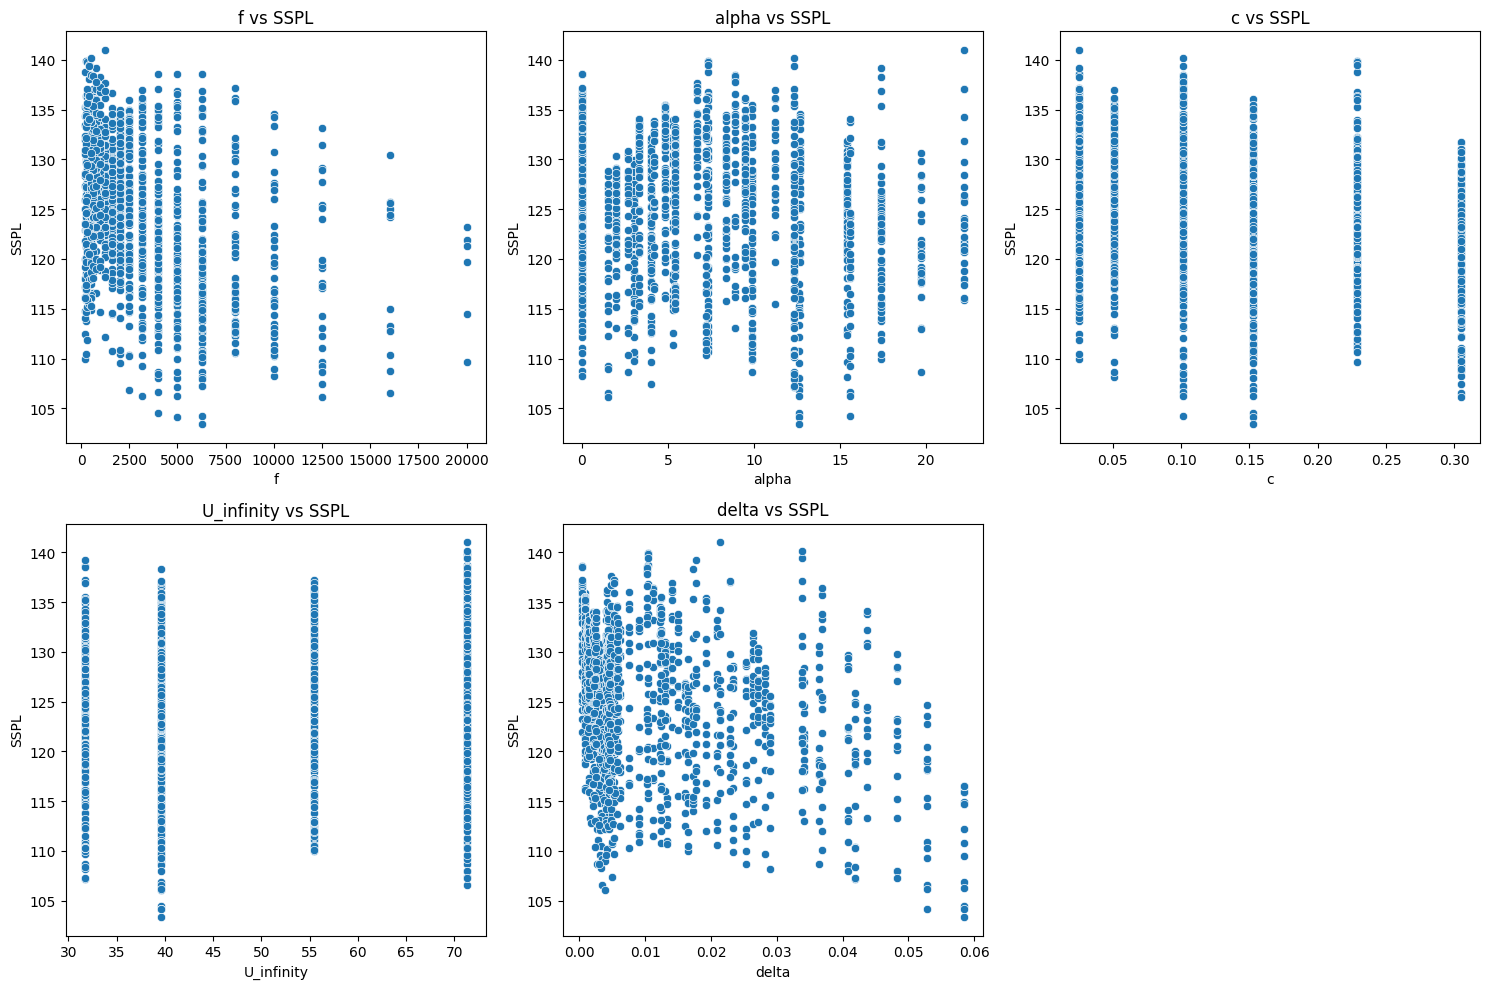

In [3]:
features = ['f', 'alpha', 'c', 'U_infinity', 'delta']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(data=df, x=feature, y='SSPL')
    plt.title(f"{feature} vs SSPL")
    plt.xlabel(feature)
    plt.ylabel("SSPL")

plt.tight_layout()
plt.show()

In [4]:
X = df.drop(columns=["SSPL"])  
y = df["SSPL"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)
print(f"Erreur quadratique moyenne (MSE) : {rmse_lr:.2f}")
print(f"Score R² : {r2_lr:.2f}")

Erreur quadratique moyenne (MSE) : 4.70
Score R² : 0.56


In [5]:
from sklearn.linear_model import Ridge, Lasso

model = Ridge(alpha=1.0)  
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse_rdg = np.sqrt(mean_squared_error(y_test, y_pred))
r2_rdg = r2_score(y_test, y_pred)
print(f"Erreur quadratique moyenne (MSE) : {rmse_rdg:.2f}")
print(f"Score R² : {r2_rdg:.2f}")

Erreur quadratique moyenne (MSE) : 4.70
Score R² : 0.56


In [6]:
model = Lasso(alpha=1.0)  
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse_lsso = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lsso = r2_score(y_test, y_pred)
print(f"Erreur quadratique moyenne (MSE) : {rmse_lsso:.2f}")
print(f"Score R² : {r2_lsso:.2f}")

Erreur quadratique moyenne (MSE) : 5.73
Score R² : 0.35


In [7]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

In [8]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9
af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  

X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
X_train_af.head()
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")




model_af = LinearRegression()
af_rmse_lin, af_r2_lin = evaluate_model(model_af, X_train_af, y_train, X_test_af, y_test)
print(f" lineaire -- rmse , r2 : {af_rmse_lin:.2f}, {af_r2_lin:.2f}")

ridge_model = Ridge(alpha=1.0)
af_rmse_ridge, af_r2_ridge = evaluate_model(ridge_model, X_train_af, y_train, X_test_af, y_test)
print(f"ridge -- rmse , r2 : {af_rmse_ridge:.2f}, {af_r2_ridge:.2f}")

lasso_model = Lasso(alpha=1.0)
af_rmse_lasso, af_r2_lasso = evaluate_model(lasso_model, X_train_af, y_train, X_test_af, y_test)
print(f"lasso -- rmse , r2 : {af_rmse_lasso:.2f}, {af_r2_lasso:.2f}")


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


Nombre de nouvelles features créées : 53
 lineaire -- rmse , r2 : 2.94, 0.83
ridge -- rmse , r2 : 2.93, 0.83
lasso -- rmse , r2 : 5.32, 0.44


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [9]:

es = ft.EntitySet(id = 'airfoil')

es.add_dataframe(dataframe_name = 'airfoil', dataframe = df, index = 'index')

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\entityset\entityset.py:1733: UserWarning: index index not found in dataframe, creating new integer column
  warnings.warn(


Entityset: airfoil
  DataFrames:
    airfoil [Rows: 1503, Columns: 7]
  Relationships:
    No relationships

In [10]:
feature_matrix, feature_names = ft.dfs(entityset=es, 
target_dataframe_name = 'airfoil', 
max_depth = 2, 
verbose = 1, 
n_jobs = 1)
feature_matrix.head()

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\synthesis\deep_feature_synthesis.py:169: UserWarning: Only one dataframe in entityset, changing max_depth to 1 since deeper features cannot be created
  warnings.warn(


Built 6 features
Elapsed: 00:00 | Progress: 100%|██████████


,f,alpha,c,U_infinity,delta,SSPL
index,,,,,,
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


On peut constater que l'application de feature tools sur ce dataset n'ajoute pas de nouvelle colonnes du au fait que ne puisse extraire une sous table pour la construction de ensemble d'entité dans feature tools.

L'application donc des modèles de regression sur le même dataset nous donnera  les même résultats que sans autoFE.

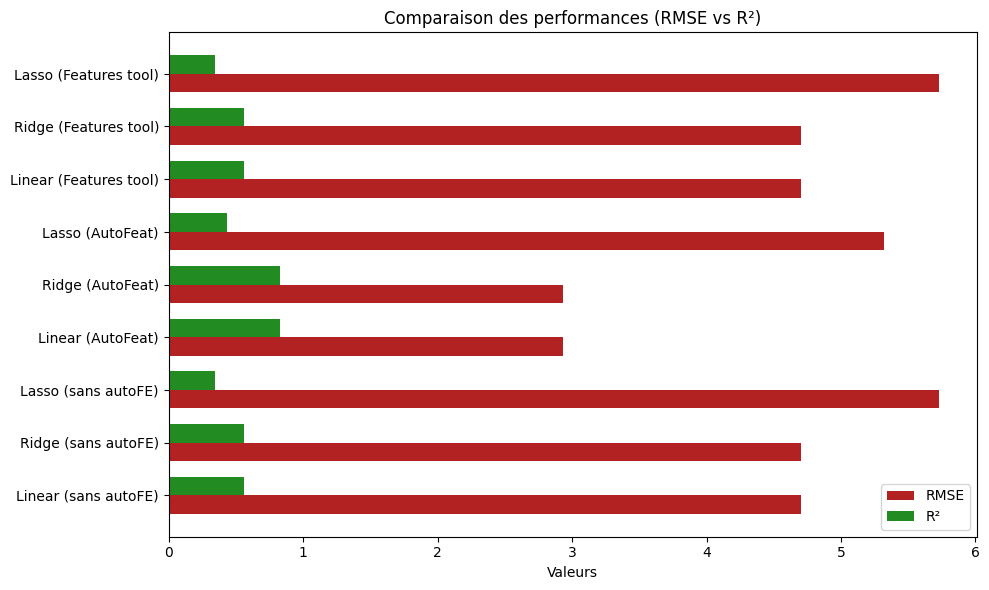

In [11]:
import matplotlib.pyplot as plt
import numpy as np


model_labels = [
    "Linear (sans autoFE)", "Ridge (sans autoFE)", "Lasso (sans autoFE)",
    "Linear (AutoFeat)", "Ridge (AutoFeat)", "Lasso (AutoFeat)",
    "Linear (Features tool)", "Ridge (Features tool)", "Lasso (Features tool)",
]

rmse_values = [rmse_lr, rmse_rdg, rmse_lsso, af_rmse_lin, af_rmse_ridge, af_rmse_lasso,rmse_lr, rmse_rdg, rmse_lsso]
r2_values   = [r2_lr,  r2_rdg,  r2_lsso,  af_r2_lin,  af_r2_ridge,  af_r2_lasso,r2_lr,  r2_rdg,  r2_lsso]

y = np.arange(len(model_labels))  
bar_height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(y - bar_height/2, rmse_values, height=bar_height, color='firebrick', label='RMSE')

ax.barh(y + bar_height/2, r2_values, height=bar_height, color='forestgreen', label='R²')

ax.set_yticks(y)
ax.set_yticklabels(model_labels)
ax.set_xlabel("Valeurs")
ax.set_title("Comparaison des performances (RMSE vs R²)")
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()
